# Fair Small-Data Ariel Experiment: Runtime × Data Size

Compare **Codex hybrid** vs a **Codex classical control** across:
- **Runtime**: total training time budget (seconds). Training must be stopped by time, not by completing all epochs.
- **Data size**: number of training rows.

This notebook now runs **two fairness views** side by side:
1. **Shared-backbone continuation**: train a classical stage 1 backbone, then compare a hybrid continuation against a classical-only continuation from the same checkpoint.
2. **End-to-end from scratch**: train a hybrid model from scratch against a matched classical-only control from scratch with the same per-model runtime budget.

The shared-backbone view is better for isolating the quantum contribution. The end-to-end view gives the hybrid model a fairer chance to co-adapt its representation with the quantum branch from the start.

**Constraints:**
1. **Epochs never end before runtime**: we set `max_epochs` high enough that the runtime limit should hit first.
2. **Shared-backbone stage 2 is matched**: the hybrid and classical continuations start from the same checkpoint and receive the same stage-2 runtime.
3. **End-to-end is matched**: the hybrid-from-scratch and classical-from-scratch runs use the same backend, data split, and wall-clock budget.
4. **We keep both comparisons**: one isolates the added quantum branch, the other tests whether joint optimization helps the hybrid model realize an advantage.

In [19]:
from pathlib import Path
import sys

expected_python = Path.cwd() / ".venv" / "bin" / "python"
print("Python executable:", sys.executable)
if expected_python.exists() and Path(sys.executable).resolve() != expected_python.resolve():
    raise RuntimeError(
        "Wrong notebook kernel. Switch to `Python (.venv AXION notebooks)` and rerun. "
        f"Expected: {expected_python} | Current: {sys.executable}"
    )

Python executable: /Users/jkw/Documents/uni/axion/hack4sages/.venv/bin/python


In [20]:
from __future__ import annotations

import importlib.util
import json
import os
import platform
import random
import shutil
import sys
from datetime import datetime
from pathlib import Path
import time

import numpy as np
import torch

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (
            (candidate / "models" / "ariel_quantum_regression" / "training.py").exists()
            and (candidate / "models" / "sbi_ariel_adc2023" / "training.py").exists()
        ):
            return candidate
        nested_root = candidate / "ariel" / "models" / "notebooks"
        if (
            (nested_root / "models" / "ariel_quantum_regression" / "training.py").exists()
            and (nested_root / "models" / "sbi_ariel_adc2023" / "training.py").exists()
        ):
            return nested_root
    raise FileNotFoundError("Could not locate the Ariel notebook project root.")


def find_data_root(project_root: Path) -> Path:
    override = os.environ.get("ARIEL_DATA_ROOT")
    if override:
        root = Path(override).expanduser().resolve()
        if (root / "TrainingData" / "AuxillaryTable.csv").exists() and (root / "TestData" / "AuxillaryTable.csv").exists():
            return root
    for candidate in [
        project_root.parent.parent,
        project_root / "data" / "ariel-ml-dataset",
        project_root / "data" / "full-ariel",
        project_root.parent.parent / "ariel-ml-dataset",
    ]:
        if (candidate / "TrainingData" / "AuxillaryTable.csv").exists() and (candidate / "TestData" / "AuxillaryTable.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate the Ariel dataset root. Set ARIEL_DATA_ROOT if needed.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_ROOT = find_data_root(PROJECT_ROOT)

# Leave this as None for a clean quantum-vs-classical-control run across both comparison modes.
RESUME_RUN_TAG = None
RUN_TAG = RESUME_RUN_TAG or datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "fair_small_experiment" / RUN_TAG
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SEED = 42
VALIDATION_ROWS = 64
HOLDOUT_ROWS = 64

# Experiment grid: which runtimes (seconds) and train sizes to sweep
RUNTIME_SECONDS_LIST = [400]
TRAIN_ROWS_LIST = [128]
COMPARISON_MODES = ["shared_backbone", "end_to_end"]

HIGH_MAX_EPOCHS = 2000

# Shared-backbone comparison: allocate part of the runtime to a classical stage 1 backbone.
# The remaining time becomes the shared stage-2 budget used by both continuations.
CODEX_STAGE1_FRACTION = 0.15
MIN_STAGE2_SECONDS = 10.0

# Codex hyperparameters
CODEX_QNN_QUBITS = 8
CODEX_QNN_DEPTH = 2
CODEX_STAGE1_BATCH_SIZE = 256
CODEX_STAGE1_EVAL_BATCH_SIZE = 512
CODEX_STAGE1_EARLY_STOP = HIGH_MAX_EPOCHS
CODEX_STAGE1_SCHEDULER_PATIENCE = 25
CODEX_STAGE1_CLASSICAL_LR = 1.0e-3
CODEX_STAGE2_BATCH_SIZE = 16
CODEX_STAGE2_EVAL_BATCH_SIZE = 32
CODEX_STAGE2_EARLY_STOP = HIGH_MAX_EPOCHS
CODEX_STAGE2_SCHEDULER_PATIENCE = 25
CODEX_STAGE2_CLASSICAL_LR = 5.0e-5
CODEX_STAGE2_QUANTUM_LR = 4.0e-4
CODEX_STAGE2_WARMUP_EPOCHS = 0
CODEX_STAGE2_RAMP_EPOCHS = 3
CODEX_STAGE2_FREEZE_EPOCHS = 0

# End-to-end comparison: reuse the quantum-friendly small-batch setup, but train from scratch.
CODEX_END_TO_END_BATCH_SIZE = CODEX_STAGE2_BATCH_SIZE
CODEX_END_TO_END_EVAL_BATCH_SIZE = CODEX_STAGE2_EVAL_BATCH_SIZE
CODEX_END_TO_END_EARLY_STOP = HIGH_MAX_EPOCHS
CODEX_END_TO_END_SCHEDULER_PATIENCE = CODEX_STAGE2_SCHEDULER_PATIENCE
CODEX_END_TO_END_CLASSICAL_LR = CODEX_STAGE1_CLASSICAL_LR
CODEX_END_TO_END_QUANTUM_LR = CODEX_STAGE2_QUANTUM_LR
CODEX_END_TO_END_WARMUP_EPOCHS = CODEX_STAGE2_WARMUP_EPOCHS
CODEX_END_TO_END_RAMP_EPOCHS = CODEX_STAGE2_RAMP_EPOCHS
CODEX_END_TO_END_FREEZE_EPOCHS = CODEX_STAGE2_FREEZE_EPOCHS

CODEX_DROPOUT = 0.05
CODEX_WEIGHT_DECAY = 1.0e-4
CODEX_GRADIENT_CLIP = 5.0
CODEX_QNN_INIT_SCALE = 0.1
CODEX_QUANTUM_GATE_INIT = 0.1
CODEX_USE_AMP = True
CODEX_LOG_EVERY_BATCHES = 0
CODEX_LOG_EVERY_EPOCHS = 5

FMPE_PATIENCE = 500
FMPE_BATCH_SIZE = 64
FMPE_EVAL_BATCH_SIZE = 128
FMPE_POSTERIOR_SAMPLES = 32
FMPE_PERIODIC_SAMPLES = 16
FMPE_CONTEXT_BATCH_SIZE = 16

DEVICE = torch.device("cpu")
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

config = {
    "project_root": str(PROJECT_ROOT),
    "data_root": str(DATA_ROOT),
    "output_root": str(OUTPUT_ROOT),
    "runtime_seconds_list": RUNTIME_SECONDS_LIST,
    "train_rows_list": TRAIN_ROWS_LIST,
    "comparison_modes": COMPARISON_MODES,
    "high_max_epochs": HIGH_MAX_EPOCHS,
    "codex_stage1_fraction": CODEX_STAGE1_FRACTION,
    "min_stage2_seconds": MIN_STAGE2_SECONDS,
}
print(json.dumps(config, indent=2))

{
  "project_root": "/Users/jkw/Documents/uni/axion/hack4sages/ariel/models/notebooks",
  "data_root": "/Users/jkw/Documents/uni/axion/hack4sages/ariel",
  "output_root": "/Users/jkw/Documents/uni/axion/hack4sages/ariel/models/notebooks/outputs/fair_small_experiment/20260312_153029",
  "runtime_seconds_list": [
    400
  ],
  "train_rows_list": [
    128
  ],
  "comparison_modes": [
    "shared_backbone",
    "end_to_end"
  ],
  "high_max_epochs": 2000,
  "codex_stage1_fraction": 0.15,
  "min_stage2_seconds": 10.0
}


In [21]:
# Dependencies and imports
required_modules = {
    "numpy": "numpy", "pandas": "pandas", "h5py": "h5py", "PyYAML": "yaml",
    "PyTorch": "torch", "scikit-learn": "sklearn", "PennyLane": "pennylane", "Dingo": "dingo",
}
missing = [label for label, mod in required_modules.items() if importlib.util.find_spec(mod) is None]
if missing:
    raise RuntimeError(f"Missing: {missing}")

import h5py
import pandas as pd
import pennylane as qml
import yaml
from sklearn.model_selection import train_test_split

from models.sbi_ariel_adc2023.constants import (
    AUX_FEATURE_COLS as FMPE_AUX_FEATURE_COLS,
    CONTEXT_DIM,
    CONTEXT_FILENAME_TEMPLATE,
    DATASET_TYPE,
    HOLDOUT_SPLIT,
    LOG10_AUX_FEATURE_COLS as FMPE_LOG10_AUX_FEATURE_COLS,
    MANIFEST_FILENAME,
    METADATA_FILENAME_TEMPLATE,
    NORMALIZATION_FILENAME,
    NORMALIZATION_MODE,
    RAW_TARGET_FILENAME_TEMPLATE,
    TARGET_COLS,
    TARGET_FILENAME_TEMPLATE,
    TESTDATA_SPLIT,
    THETA_DIM,
    TRAIN_SPLIT,
    VALIDATION_SPLIT,
    WAVELENGTH_FILENAME,
)
from models.sbi_ariel_adc2023.evaluate import run_regression_evaluation
from models.ariel_quantum_regression.constants import (
    AUX_COLUMNS as CODEX_AUX_COLUMNS,
    FIXED_SPECTRAL_CHANNELS,
    HDF5_GROUP_PREFIX,
    LOG10_AUX_COLUMNS as CODEX_LOG10_AUX_COLUMNS,
    MODEL_SPECTRAL_CHANNELS,
    PRESENCE_THRESHOLD_LOG10_VMR,
    RAW_SPECTRAL_CHANNELS,
    SAMPLE_SPECTRAL_CHANNELS,
    TARGET_COLUMNS as CODEX_TARGET_COLUMNS,
    WAVELENGTH_DATASET,
)
from models.ariel_quantum_regression.dataset import (
    ArrayStandardizer,
    PreparedData,
    SpectralStandardizer,
    _expected_manifest,
    _make_inference_split,
    _make_labeled_split,
    _normalize_fixed_channel,
    _normalize_sample_spectra,
    _save_prepared_cache,
    build_stratify_labels,
    transform_aux_features,
)

import importlib
import models.sbi_ariel_adc2023.training as fmpe_training_module
import models.ariel_quantum_regression.model as codex_model_module
import models.ariel_quantum_regression.training as codex_training_module
importlib.reload(fmpe_training_module)
importlib.reload(codex_model_module)
importlib.reload(codex_training_module)
train_model = fmpe_training_module.train_model
TrainingConfig = codex_training_module.TrainingConfig
run_training_experiment = codex_training_module.run_training_experiment

TRAINING_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
QUANTUM_DEVICE = "lightning.gpu" if torch.cuda.is_available() else "lightning.qubit"
print(f"Device: {DEVICE} | Training backend: {TRAINING_DEVICE} | Quantum backend: {QUANTUM_DEVICE}")

Device: cpu | Training backend: cpu | Quantum backend: lightning.qubit


In [22]:
def _drop_unnamed_columns(frame: pd.DataFrame) -> pd.DataFrame:
    unnamed = [c for c in frame.columns if c.startswith("Unnamed:")]
    if unnamed:
        frame = frame.drop(columns=unnamed)
    return frame

def _load_spectra(hdf5_path: Path, planet_ids: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    spectra = np.empty((len(planet_ids), 52, len(RAW_SPECTRAL_CHANNELS)), dtype=np.float32)
    wavelength_um = None
    with h5py.File(hdf5_path, "r") as handle:
        for row_index, planet_id in enumerate(planet_ids.tolist()):
            group = handle[f"{HDF5_GROUP_PREFIX}{planet_id}"]
            row_wavelength = np.asarray(group[WAVELENGTH_DATASET][:], dtype=np.float32)
            if wavelength_um is None:
                wavelength_um = row_wavelength
            elif not np.allclose(row_wavelength, wavelength_um, atol=1.0e-8):
                raise AssertionError(f"Wavelength mismatch for {planet_id}")
            for channel_index, channel_name in enumerate(RAW_SPECTRAL_CHANNELS):
                spectra[row_index, :, channel_index] = np.asarray(group[channel_name][:], dtype=np.float32)
    if wavelength_um is None:
        raise RuntimeError(f"No spectra found in {hdf5_path}")
    return spectra, wavelength_um

train_aux_df = _drop_unnamed_columns(pd.read_csv(DATA_ROOT / "TrainingData" / "AuxillaryTable.csv"))
train_targets_df = _drop_unnamed_columns(
    pd.read_csv(DATA_ROOT / "TrainingData" / "Ground Truth Package" / "FM_Parameter_Table.csv")
)
labels = train_aux_df.merge(train_targets_df[["planet_ID", *TARGET_COLS]], on="planet_ID", how="inner", validate="one_to_one")
labels = labels.reset_index(drop=True)

train_spectra_raw, wavelength_um = _load_spectra(
    DATA_ROOT / "TrainingData" / "SpectralData.hdf5",
    labels["planet_ID"].to_numpy(dtype="U32"),
)
test_aux_df = _drop_unnamed_columns(pd.read_csv(DATA_ROOT / "TestData" / "AuxillaryTable.csv"))
test_spectra_raw, test_wavelength_um = _load_spectra(
    DATA_ROOT / "TestData" / "SpectralData.hdf5",
    test_aux_df["planet_ID"].to_numpy(dtype="U32"),
)
assert np.allclose(wavelength_um, test_wavelength_um, atol=1.0e-8), "Wavelength grids do not match."
targets_raw = labels[TARGET_COLS].to_numpy(dtype=np.float32, copy=True)
print(f"Training rows: {len(labels):,} | Test rows: {len(test_aux_df):,} | Wavelength bins: {len(wavelength_um)}")

Training rows: 41,423 | Test rows: 685 | Wavelength bins: 52


In [23]:
# Fixed train/val/holdout pools (same split logic as fair_small_compare)
all_indices = np.arange(len(labels), dtype=np.int64)
stratify_all, stratify_mode_all = build_stratify_labels(targets_raw)
train_pool, temp_pool = train_test_split(
    all_indices, test_size=0.2, random_state=SEED, shuffle=True,
    stratify=stratify_all if stratify_all is not None else None,
)
temp_targets_raw = targets_raw[temp_pool]
stratify_temp, stratify_mode_temp = build_stratify_labels(temp_targets_raw)
temp_positions = np.arange(len(temp_pool), dtype=np.int64)
validation_positions, holdout_positions = train_test_split(
    temp_positions, test_size=0.5, random_state=SEED + 1, shuffle=True,
    stratify=stratify_temp if stratify_temp is not None else None,
)
validation_pool = temp_pool[validation_positions]
holdout_pool = temp_pool[holdout_positions]
rng = np.random.default_rng(SEED)

def take_subset(indices: np.ndarray, limit: int) -> np.ndarray:
    if limit >= len(indices):
        return np.sort(indices.astype(np.int64))
    chosen = rng.choice(indices, size=int(limit), replace=False)
    return np.sort(chosen.astype(np.int64))

print("Pools ready. Use take_subset(train_pool, n) for each train_rows in the grid.")

Pools ready. Use take_subset(train_pool, n) for each train_rows in the grid.


In [24]:
def safe_scale(values: np.ndarray) -> np.ndarray:
    scale = values.std(axis=0, ddof=0).astype(np.float32)
    return np.where(scale == 0.0, 1.0, scale).astype(np.float32)

def normalize_spectrum(values: np.ndarray) -> np.ndarray:
    sample_mean = values.mean(axis=1, keepdims=True)
    sample_mean = np.clip(sample_mean, 1.0e-12, None)
    return (values / sample_mean).astype(np.float32)

def log_noise(values: np.ndarray) -> np.ndarray:
    return np.log10(np.clip(values.astype(np.float32), 1.0e-12, None)).astype(np.float32)

def compute_zscore(values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    mean = values.mean(axis=0).astype(np.float32)
    scale = safe_scale(values)
    return mean, scale

def apply_zscore(values: np.ndarray, mean: np.ndarray, scale: np.ndarray) -> np.ndarray:
    return ((values - mean) / scale).astype(np.float32)

def metadata_frame(indices: np.ndarray) -> pd.DataFrame:
    return pd.DataFrame({
        "planet_ID": labels.iloc[indices]["planet_ID"].to_numpy(dtype="U32"),
        "source_row_index": indices.astype(np.int64),
    })

def build_prepared_data(experiment_dir: Path, train_idx: np.ndarray, validation_idx: np.ndarray, holdout_idx: np.ndarray):
    """Build shared split, Codex cache, and FMPE prepared dataset for given indices. Returns (codex_cache_dir, fmpe_prepared_dir, shared_split_path)."""
    experiment_dir = Path(experiment_dir)
    experiment_dir.mkdir(parents=True, exist_ok=True)
    shared_split_path = experiment_dir / "shared_split.csv"
    split_frame = pd.DataFrame({
        "split": ([TRAIN_SPLIT] * len(train_idx)) + ([VALIDATION_SPLIT] * len(validation_idx)) + ([HOLDOUT_SPLIT] * len(holdout_idx)),
        "planet_ID": np.concatenate([
            labels.iloc[train_idx]["planet_ID"].to_numpy(dtype="U32"),
            labels.iloc[validation_idx]["planet_ID"].to_numpy(dtype="U32"),
            labels.iloc[holdout_idx]["planet_ID"].to_numpy(dtype="U32"),
        ]),
        "source_row_index": np.concatenate([train_idx, validation_idx, holdout_idx]),
    })
    split_frame.to_csv(shared_split_path, index=False)
    (experiment_dir / "shared_split_manifest.json").write_text(
        json.dumps({"seed": SEED, "train_rows": len(train_idx), "validation_rows": len(validation_idx), "holdout_rows": len(holdout_idx), "shared_split_file": str(shared_split_path)}, indent=2) + "\n"
    )

    # Codex
    codex_cache_dir = experiment_dir / "codex_prepared_cache"
    if codex_cache_dir.exists():
        shutil.rmtree(codex_cache_dir)
    codex_cache_dir.mkdir(parents=True, exist_ok=True)
    codex_aux_raw = transform_aux_features(labels)
    codex_test_aux_raw = transform_aux_features(test_aux_df)
    codex_targets_raw = labels[CODEX_TARGET_COLUMNS].to_numpy(dtype=np.float32, copy=True)
    sample_channel_indices = [RAW_SPECTRAL_CHANNELS.index(n) for n in SAMPLE_SPECTRAL_CHANNELS]
    width_channel_index = RAW_SPECTRAL_CHANNELS.index("instrument_width")
    codex_train_sample_spectra = np.transpose(train_spectra_raw[:, :, sample_channel_indices], (0, 2, 1)).astype(np.float32)
    codex_test_sample_spectra = np.transpose(test_spectra_raw[:, :, sample_channel_indices], (0, 2, 1)).astype(np.float32)
    codex_train_sample_spectra = _normalize_sample_spectra(codex_train_sample_spectra)
    codex_test_sample_spectra = _normalize_sample_spectra(codex_test_sample_spectra)
    fixed_channels = np.stack([
        _normalize_fixed_channel(train_spectra_raw[0, :, width_channel_index]),
        _normalize_fixed_channel(wavelength_um),
    ], axis=0).astype(np.float32)
    codex_aux_scaler = ArrayStandardizer.fit(codex_aux_raw[train_idx])
    codex_target_scaler = ArrayStandardizer.fit(codex_targets_raw[train_idx])
    codex_spectral_scaler = SpectralStandardizer.fit(codex_train_sample_spectra[train_idx], fixed_channels=fixed_channels)

    def make_codex_labeled_split(indices):
        return _make_labeled_split(
            planet_ids=labels.iloc[indices]["planet_ID"].to_numpy(dtype="U32"),
            aux_values=codex_aux_scaler.transform(codex_aux_raw[indices]),
            spectra_values=codex_spectral_scaler.transform(codex_train_sample_spectra[indices]),
            targets_scaled=codex_target_scaler.transform(codex_targets_raw[indices]),
            raw_targets=codex_targets_raw[indices],
        )
    codex_test_split = _make_inference_split(
        planet_ids=test_aux_df["planet_ID"].to_numpy(dtype="U32"),
        aux_values=codex_aux_scaler.transform(codex_test_aux_raw),
        spectra_values=codex_spectral_scaler.transform(codex_test_sample_spectra),
    )
    codex_split_manifest = {
        "train_rows": len(train_idx), "val_rows": len(validation_idx), "holdout_rows": len(holdout_idx),
        "shared_split_file": str(shared_split_path),
        "wavelength_bins": len(wavelength_um), "target_columns": CODEX_TARGET_COLUMNS,
    }
    codex_expected_manifest = _expected_manifest(DATA_ROOT, SEED, len(train_idx), len(validation_idx), len(holdout_idx), None)
    codex_prepared_manifest = dict(codex_expected_manifest)
    codex_prepared_manifest["cache_dir"] = str(codex_cache_dir)
    codex_prepared_manifest["cache_hit"] = False
    codex_prepared = PreparedData(
        train=make_codex_labeled_split(train_idx), val=make_codex_labeled_split(validation_idx),
        holdout=make_codex_labeled_split(holdout_idx), testdata=codex_test_split,
        aux_scaler=codex_aux_scaler, target_scaler=codex_target_scaler, spectral_scaler=codex_spectral_scaler,
        wavelength_um=wavelength_um.astype(np.float32), split_manifest=codex_split_manifest, prepared_manifest=codex_prepared_manifest,
    )
    _save_prepared_cache(codex_cache_dir, codex_expected_manifest, codex_prepared)

    # FMPE
    fmpe_prepared_dir = experiment_dir / "fmpe_prepared_dataset"
    if fmpe_prepared_dir.exists():
        shutil.rmtree(fmpe_prepared_dir)
    fmpe_prepared_dir.mkdir(parents=True, exist_ok=True)
    fmpe_labeled_spectrum = normalize_spectrum(train_spectra_raw[:, :, RAW_SPECTRAL_CHANNELS.index("instrument_spectrum")])
    fmpe_test_spectrum = normalize_spectrum(test_spectra_raw[:, :, RAW_SPECTRAL_CHANNELS.index("instrument_spectrum")])
    fmpe_labeled_noise = log_noise(train_spectra_raw[:, :, RAW_SPECTRAL_CHANNELS.index("instrument_noise")])
    fmpe_test_noise = log_noise(test_spectra_raw[:, :, RAW_SPECTRAL_CHANNELS.index("instrument_noise")])
    fmpe_labeled_aux = labels[FMPE_AUX_FEATURE_COLS].to_numpy(dtype=np.float32, copy=True)
    fmpe_test_aux = test_aux_df[FMPE_AUX_FEATURE_COLS].to_numpy(dtype=np.float32, copy=True)
    for col_index, col_name in enumerate(FMPE_AUX_FEATURE_COLS):
        if col_name in FMPE_LOG10_AUX_FEATURE_COLS:
            fmpe_labeled_aux[:, col_index] = np.log10(np.clip(fmpe_labeled_aux[:, col_index], 1.0e-12, None))
            fmpe_test_aux[:, col_index] = np.log10(np.clip(fmpe_test_aux[:, col_index], 1.0e-12, None))
    fmpe_targets_raw = labels[TARGET_COLS].to_numpy(dtype=np.float32, copy=True)
    spectrum_mean, spectrum_scale = compute_zscore(fmpe_labeled_spectrum[train_idx])
    noise_mean, noise_scale = compute_zscore(fmpe_labeled_noise[train_idx])
    aux_mean, aux_scale = compute_zscore(fmpe_labeled_aux[train_idx])
    target_mean, target_scale = compute_zscore(fmpe_targets_raw[train_idx])

    def fmpe_context(indices):
        return np.concatenate([
            apply_zscore(fmpe_labeled_spectrum[indices], spectrum_mean, spectrum_scale),
            apply_zscore(fmpe_labeled_noise[indices], noise_mean, noise_scale),
            apply_zscore(fmpe_labeled_aux[indices], aux_mean, aux_scale),
        ], axis=1).astype(np.float32)

    def write_fmpe_split(split_name, indices):
        np.save(fmpe_prepared_dir / CONTEXT_FILENAME_TEMPLATE.format(split_name=split_name), fmpe_context(indices))
        np.save(fmpe_prepared_dir / TARGET_FILENAME_TEMPLATE.format(split_name=split_name), apply_zscore(fmpe_targets_raw[indices], target_mean, target_scale))
        np.save(fmpe_prepared_dir / RAW_TARGET_FILENAME_TEMPLATE.format(split_name=split_name), fmpe_targets_raw[indices].astype(np.float32))
        metadata_frame(indices).to_csv(fmpe_prepared_dir / METADATA_FILENAME_TEMPLATE.format(split_name=split_name), index=False)
    write_fmpe_split(TRAIN_SPLIT, train_idx)
    write_fmpe_split(VALIDATION_SPLIT, validation_idx)
    write_fmpe_split(HOLDOUT_SPLIT, holdout_idx)
    test_context = np.concatenate([
        apply_zscore(fmpe_test_spectrum, spectrum_mean, spectrum_scale),
        apply_zscore(fmpe_test_noise, noise_mean, noise_scale),
        apply_zscore(fmpe_test_aux, aux_mean, aux_scale),
    ], axis=1).astype(np.float32)
    np.save(fmpe_prepared_dir / CONTEXT_FILENAME_TEMPLATE.format(split_name=TESTDATA_SPLIT), test_context)
    pd.DataFrame({"planet_ID": test_aux_df["planet_ID"].to_numpy(dtype="U32"), "source_row_index": np.arange(len(test_aux_df), dtype=np.int64)}).to_csv(fmpe_prepared_dir / METADATA_FILENAME_TEMPLATE.format(split_name=TESTDATA_SPLIT), index=False)
    np.savez(fmpe_prepared_dir / NORMALIZATION_FILENAME, spectrum_mean=spectrum_mean, spectrum_scale=spectrum_scale, noise_mean=noise_mean, noise_scale=noise_scale, aux_mean=aux_mean, aux_scale=aux_scale, target_mean=target_mean, target_scale=target_scale)
    np.save(fmpe_prepared_dir / WAVELENGTH_FILENAME, wavelength_um.astype(np.float32))
    (fmpe_prepared_dir / MANIFEST_FILENAME).write_text(json.dumps({
        "data_root": str(DATA_ROOT), "prepared_dir": str(fmpe_prepared_dir), "dataset_type": DATASET_TYPE, "normalization_mode": NORMALIZATION_MODE,
        "seed": SEED, "split_counts": {TRAIN_SPLIT: len(train_idx), VALIDATION_SPLIT: len(validation_idx), HOLDOUT_SPLIT: len(holdout_idx), TESTDATA_SPLIT: len(test_aux_df)},
        "context_dim": CONTEXT_DIM, "theta_dim": THETA_DIM, "target_columns": TARGET_COLS, "shared_split_file": str(shared_split_path),
    }, indent=2, sort_keys=True) + "\n")
    return codex_cache_dir, fmpe_prepared_dir, shared_split_path

In [25]:
# Run experiment grid for two fair comparisons:
# 1. shared-backbone continuation
# 2. end-to-end from scratch
results = []


def append_result(
    *,
    comparison_mode: str,
    runtime_seconds: int,
    train_rows: int,
    stage1_budget_seconds: float | None,
    branch_budget_seconds: float,
    stage1_summary: dict | None,
    hybrid_summary: dict,
    classical_summary: dict,
) -> None:
    hybrid_holdout_rmse = float(hybrid_summary["holdout_rmse_mean"])
    classical_holdout_rmse = float(classical_summary["holdout_rmse_mean"])
    results.append({
        "comparison_mode": comparison_mode,
        "runtime_seconds": runtime_seconds,
        "train_rows": train_rows,
        "stage1_budget_seconds": stage1_budget_seconds,
        "branch_budget_seconds": float(branch_budget_seconds),
        "stage1_holdout_rmse_mean": None if stage1_summary is None else float(stage1_summary["holdout_rmse_mean"]),
        "hybrid_holdout_rmse_mean": hybrid_holdout_rmse,
        "classical_holdout_rmse_mean": classical_holdout_rmse,
        "hybrid_advantage_rmse_mean": classical_holdout_rmse - hybrid_holdout_rmse,
        "hybrid_ran": int(hybrid_summary.get("best_epoch", 0)) >= 1,
        "classical_ran": int(classical_summary.get("best_epoch", 0)) >= 1,
        "stage1_status": None if stage1_summary is None else stage1_summary.get("status"),
        "hybrid_status": hybrid_summary.get("status"),
        "classical_status": classical_summary.get("status"),
    })


for runtime_seconds in RUNTIME_SECONDS_LIST:
    for train_rows in TRAIN_ROWS_LIST:
        experiment_dir = OUTPUT_ROOT / f"runtime_{runtime_seconds}s_data_{train_rows}"
        train_idx = take_subset(train_pool, train_rows)
        validation_idx = take_subset(validation_pool, VALIDATION_ROWS)
        holdout_idx = take_subset(holdout_pool, HOLDOUT_ROWS)

        codex_cache_dir, _, _ = build_prepared_data(experiment_dir, train_idx, validation_idx, holdout_idx)

        def make_codex_cfg(
            out_dir,
            budget_s,
            *,
            batch_size,
            eval_batch_size,
            classical_lr,
            early_stop_patience,
            scheduler_patience,
            classical_only,
            quantum_lr=0.0,
            init_checkpoint_path=None,
            quantum_warmup_epochs=0,
            quantum_ramp_epochs=0,
            quantum_backbone_freeze_epochs=0,
        ):
            return TrainingConfig(
                project_root=str(PROJECT_ROOT),
                data_root=str(DATA_ROOT),
                output_dir=str(out_dir),
                prepared_cache_dir=str(codex_cache_dir),
                init_checkpoint_path=None if init_checkpoint_path is None else str(init_checkpoint_path),
                seed=SEED,
                batch_size=batch_size,
                eval_batch_size=eval_batch_size,
                max_epochs=HIGH_MAX_EPOCHS,
                max_runtime_seconds=budget_s,
                early_stop_patience=early_stop_patience,
                scheduler_patience=scheduler_patience,
                scheduler_factor=0.5,
                classical_lr=classical_lr,
                quantum_lr=0.0 if classical_only else quantum_lr,
                weight_decay=CODEX_WEIGHT_DECAY,
                gradient_clip_norm=CODEX_GRADIENT_CLIP,
                dropout=CODEX_DROPOUT,
                loss_name="mse",
                qnn_qubits=CODEX_QNN_QUBITS,
                qnn_depth=CODEX_QNN_DEPTH,
                qnn_init_scale=CODEX_QNN_INIT_SCALE,
                quantum_gate_init=CODEX_QUANTUM_GATE_INIT,
                quantum_device=QUANTUM_DEVICE,
                training_device=TRAINING_DEVICE,
                classical_only=classical_only,
                quantum_warmup_epochs=0 if classical_only else quantum_warmup_epochs,
                quantum_ramp_epochs=0 if classical_only else quantum_ramp_epochs,
                quantum_backbone_freeze_epochs=0 if classical_only else quantum_backbone_freeze_epochs,
                use_amp=CODEX_USE_AMP,
                log_every_batches=CODEX_LOG_EVERY_BATCHES,
                log_every_epochs=CODEX_LOG_EVERY_EPOCHS,
                train_limit=len(train_idx),
                val_limit=len(validation_idx),
                holdout_limit=len(holdout_idx),
            )

        if "shared_backbone" in COMPARISON_MODES:
            shared_out = experiment_dir / "codex_shared_backbone"
            stage1_dir = shared_out / "stage1_classical"
            stage2_hybrid_dir = shared_out / "stage2_hybrid"
            stage2_classical_dir = shared_out / "stage2_classical_control"

            stage1_summary_path = stage1_dir / "run_summary.json"
            stage2_hybrid_summary_path = stage2_hybrid_dir / "run_summary.json"
            stage2_classical_summary_path = stage2_classical_dir / "run_summary.json"
            shared_complete = (
                stage1_summary_path.exists()
                and stage2_hybrid_summary_path.exists()
                and stage2_classical_summary_path.exists()
            )

            if shared_complete:
                stage1_summary = json.loads(stage1_summary_path.read_text())
                stage2_hybrid_summary = json.loads(stage2_hybrid_summary_path.read_text())
                stage2_classical_summary = json.loads(stage2_classical_summary_path.read_text())
                stage1_budget = min(runtime_seconds * CODEX_STAGE1_FRACTION, max(1.0, runtime_seconds - MIN_STAGE2_SECONDS))
                stage2_budget = max(MIN_STAGE2_SECONDS, runtime_seconds - stage1_budget)
                print(
                    f"Skipping completed shared_backbone condition runtime={runtime_seconds}s train_rows={train_rows}"
                )
            else:
                stage1_budget = min(runtime_seconds * CODEX_STAGE1_FRACTION, max(1.0, runtime_seconds - MIN_STAGE2_SECONDS))
                if shared_out.exists():
                    shutil.rmtree(shared_out)
                shared_out.mkdir(parents=True, exist_ok=True)

                shared_start = time.perf_counter()
                stage1_cfg = make_codex_cfg(
                    stage1_dir,
                    stage1_budget,
                    batch_size=CODEX_STAGE1_BATCH_SIZE,
                    eval_batch_size=CODEX_STAGE1_EVAL_BATCH_SIZE,
                    classical_lr=CODEX_STAGE1_CLASSICAL_LR,
                    early_stop_patience=CODEX_STAGE1_EARLY_STOP,
                    scheduler_patience=CODEX_STAGE1_SCHEDULER_PATIENCE,
                    classical_only=True,
                )
                stage1_result = run_training_experiment(stage1_cfg)
                stage1_summary = stage1_result["summary"]
                stage1_ckpt = Path(stage1_dir) / "best_model.pt"
                if not stage1_ckpt.exists():
                    raise FileNotFoundError(f"Codex stage1 no checkpoint: {stage1_ckpt}")

                stage2_budget = max(MIN_STAGE2_SECONDS, runtime_seconds - (time.perf_counter() - shared_start))

                stage2_hybrid_cfg = make_codex_cfg(
                    stage2_hybrid_dir,
                    stage2_budget,
                    batch_size=CODEX_STAGE2_BATCH_SIZE,
                    eval_batch_size=CODEX_STAGE2_EVAL_BATCH_SIZE,
                    classical_lr=CODEX_STAGE2_CLASSICAL_LR,
                    quantum_lr=CODEX_STAGE2_QUANTUM_LR,
                    early_stop_patience=CODEX_STAGE2_EARLY_STOP,
                    scheduler_patience=CODEX_STAGE2_SCHEDULER_PATIENCE,
                    classical_only=False,
                    init_checkpoint_path=stage1_ckpt.resolve(),
                    quantum_warmup_epochs=CODEX_STAGE2_WARMUP_EPOCHS,
                    quantum_ramp_epochs=CODEX_STAGE2_RAMP_EPOCHS,
                    quantum_backbone_freeze_epochs=CODEX_STAGE2_FREEZE_EPOCHS,
                )
                stage2_hybrid_result = run_training_experiment(stage2_hybrid_cfg)
                stage2_hybrid_summary = stage2_hybrid_result["summary"]

                stage2_classical_cfg = make_codex_cfg(
                    stage2_classical_dir,
                    stage2_budget,
                    batch_size=CODEX_STAGE2_BATCH_SIZE,
                    eval_batch_size=CODEX_STAGE2_EVAL_BATCH_SIZE,
                    classical_lr=CODEX_STAGE2_CLASSICAL_LR,
                    early_stop_patience=CODEX_STAGE2_EARLY_STOP,
                    scheduler_patience=CODEX_STAGE2_SCHEDULER_PATIENCE,
                    classical_only=True,
                    init_checkpoint_path=stage1_ckpt.resolve(),
                )
                stage2_classical_result = run_training_experiment(stage2_classical_cfg)
                stage2_classical_summary = stage2_classical_result["summary"]

            append_result(
                comparison_mode="shared_backbone",
                runtime_seconds=runtime_seconds,
                train_rows=train_rows,
                stage1_budget_seconds=stage1_budget,
                branch_budget_seconds=stage2_budget,
                stage1_summary=stage1_summary,
                hybrid_summary=stage2_hybrid_summary,
                classical_summary=stage2_classical_summary,
            )
            print(
                f"mode=shared_backbone runtime={runtime_seconds}s train_rows={train_rows} -> "
                f"stage1_holdout_rmse={float(stage1_summary['holdout_rmse_mean']):.4f} "
                f"hybrid_holdout_rmse={float(stage2_hybrid_summary['holdout_rmse_mean']):.4f} "
                f"classical_holdout_rmse={float(stage2_classical_summary['holdout_rmse_mean']):.4f}"
            )

        if "end_to_end" in COMPARISON_MODES:
            e2e_out = experiment_dir / "codex_end_to_end"
            e2e_hybrid_dir = e2e_out / "hybrid_from_scratch"
            e2e_classical_dir = e2e_out / "classical_control_from_scratch"

            e2e_hybrid_summary_path = e2e_hybrid_dir / "run_summary.json"
            e2e_classical_summary_path = e2e_classical_dir / "run_summary.json"
            e2e_complete = e2e_hybrid_summary_path.exists() and e2e_classical_summary_path.exists()

            if e2e_complete:
                e2e_hybrid_summary = json.loads(e2e_hybrid_summary_path.read_text())
                e2e_classical_summary = json.loads(e2e_classical_summary_path.read_text())
                e2e_budget = float(runtime_seconds)
                print(f"Skipping completed end_to_end condition runtime={runtime_seconds}s train_rows={train_rows}")
            else:
                e2e_budget = float(runtime_seconds)
                if e2e_out.exists():
                    shutil.rmtree(e2e_out)
                e2e_out.mkdir(parents=True, exist_ok=True)

                e2e_hybrid_cfg = make_codex_cfg(
                    e2e_hybrid_dir,
                    e2e_budget,
                    batch_size=CODEX_END_TO_END_BATCH_SIZE,
                    eval_batch_size=CODEX_END_TO_END_EVAL_BATCH_SIZE,
                    classical_lr=CODEX_END_TO_END_CLASSICAL_LR,
                    quantum_lr=CODEX_END_TO_END_QUANTUM_LR,
                    early_stop_patience=CODEX_END_TO_END_EARLY_STOP,
                    scheduler_patience=CODEX_END_TO_END_SCHEDULER_PATIENCE,
                    classical_only=False,
                    quantum_warmup_epochs=CODEX_END_TO_END_WARMUP_EPOCHS,
                    quantum_ramp_epochs=CODEX_END_TO_END_RAMP_EPOCHS,
                    quantum_backbone_freeze_epochs=CODEX_END_TO_END_FREEZE_EPOCHS,
                )
                e2e_hybrid_result = run_training_experiment(e2e_hybrid_cfg)
                e2e_hybrid_summary = e2e_hybrid_result["summary"]

                e2e_classical_cfg = make_codex_cfg(
                    e2e_classical_dir,
                    e2e_budget,
                    batch_size=CODEX_END_TO_END_BATCH_SIZE,
                    eval_batch_size=CODEX_END_TO_END_EVAL_BATCH_SIZE,
                    classical_lr=CODEX_END_TO_END_CLASSICAL_LR,
                    early_stop_patience=CODEX_END_TO_END_EARLY_STOP,
                    scheduler_patience=CODEX_END_TO_END_SCHEDULER_PATIENCE,
                    classical_only=True,
                )
                e2e_classical_result = run_training_experiment(e2e_classical_cfg)
                e2e_classical_summary = e2e_classical_result["summary"]

            append_result(
                comparison_mode="end_to_end",
                runtime_seconds=runtime_seconds,
                train_rows=train_rows,
                stage1_budget_seconds=None,
                branch_budget_seconds=e2e_budget,
                stage1_summary=None,
                hybrid_summary=e2e_hybrid_summary,
                classical_summary=e2e_classical_summary,
            )
            print(
                f"mode=end_to_end runtime={runtime_seconds}s train_rows={train_rows} -> "
                f"hybrid_holdout_rmse={float(e2e_hybrid_summary['holdout_rmse_mean']):.4f} "
                f"classical_holdout_rmse={float(e2e_classical_summary['holdout_rmse_mean']):.4f}"
            )

Project root: /Users/jkw/Documents/uni/axion/hack4sages/ariel/models/notebooks
Data root: /Users/jkw/Documents/uni/axion/hack4sages/ariel
Output dir: /Users/jkw/Documents/uni/axion/hack4sages/ariel/models/notebooks/outputs/fair_small_experiment/20260312_153029/runtime_400s_data_128/codex_shared_backbone/stage1_classical
Batch size: 256
Eval batch size: 512
Quantum width/depth: 8/2
Quantum async: False
Loss: mse
Quantum warmup epochs: 0
Quantum ramp epochs: 0
Quantum backbone freeze epochs: 0
Prepared cache dir: /Users/jkw/Documents/uni/axion/hack4sages/ariel/models/notebooks/outputs/fair_small_experiment/20260312_153029/runtime_400s_data_128/codex_prepared_cache
Torch device: cpu | Quantum device: lightning.qubit | classical_only=True
Loss: mse | Quantum warmup epochs: 0 | Quantum ramp epochs: 0 | Backbone freeze epochs: 0
Max runtime seconds: 60.0
Epoch 1/2000 | train_loss=1.05325 | train_rmse_mean=1.48983 | val_rmse_mean=1.45599 | val_mae_mean=1.24223 | time=0.3s | lr=(1.00e-03, 0.00

In [26]:
results_df = pd.DataFrame(results).sort_values(["comparison_mode", "runtime_seconds", "train_rows"]).reset_index(drop=True)
results_df.to_csv(OUTPUT_ROOT / "experiment_results.csv", index=False)
print(
    results_df[
        [
            "comparison_mode",
            "runtime_seconds",
            "train_rows",
            "stage1_holdout_rmse_mean",
            "hybrid_holdout_rmse_mean",
            "classical_holdout_rmse_mean",
            "hybrid_advantage_rmse_mean",
            "hybrid_ran",
            "classical_ran",
            "stage1_status",
            "hybrid_status",
            "classical_status",
        ]
    ].to_string(index=False)
)

for comparison_mode, mode_df in results_df.groupby("comparison_mode", sort=False):
    if not mode_df["hybrid_ran"].all():
        print(f"WARNING [{comparison_mode}]: some hybrid runs did not train for at least one epoch.")
    elif not mode_df["classical_ran"].all():
        print(f"WARNING [{comparison_mode}]: some classical-control runs did not train for at least one epoch.")
    elif comparison_mode == "shared_backbone":
        print("All shared-backbone hybrid and classical continuations ran after the common stage-1 checkpoint.")
    elif comparison_mode == "end_to_end":
        print("All end-to-end hybrid and classical-from-scratch runs trained under the requested runtime budget.")

comparison_mode  runtime_seconds  train_rows  stage1_holdout_rmse_mean  hybrid_holdout_rmse_mean  classical_holdout_rmse_mean  hybrid_advantage_rmse_mean  hybrid_ran  classical_ran   stage1_status   hybrid_status classical_status
     end_to_end              400         128                       NaN                  1.163940                     1.111438                   -0.052502        True           True             NaN stopped_runtime  stopped_runtime
shared_backbone              400         128                  1.027268                  1.037626                     1.035473                   -0.002153        True           True stopped_runtime stopped_runtime  stopped_runtime
All end-to-end hybrid and classical-from-scratch runs trained under the requested runtime budget.
All shared-backbone hybrid and classical continuations ran after the common stage-1 checkpoint.


In [27]:
# Add winner and compact summary
results_df["winner"] = results_df.apply(
    lambda r: "hybrid"
    if r["hybrid_holdout_rmse_mean"] < r["classical_holdout_rmse_mean"]
    else ("classical" if r["classical_holdout_rmse_mean"] < r["hybrid_holdout_rmse_mean"] else "tie"),
    axis=1,
)
print("Winner by (mode, runtime, data):")
print(
    results_df[
        [
            "comparison_mode",
            "runtime_seconds",
            "train_rows",
            "stage1_holdout_rmse_mean",
            "hybrid_holdout_rmse_mean",
            "classical_holdout_rmse_mean",
            "hybrid_advantage_rmse_mean",
            "winner",
        ]
    ].to_string(index=False)
)
results_df.to_csv(OUTPUT_ROOT / "experiment_results.csv", index=False)

Winner by (mode, runtime, data):
comparison_mode  runtime_seconds  train_rows  stage1_holdout_rmse_mean  hybrid_holdout_rmse_mean  classical_holdout_rmse_mean  hybrid_advantage_rmse_mean    winner
     end_to_end              400         128                       NaN                  1.163940                     1.111438                   -0.052502 classical
shared_backbone              400         128                  1.027268                  1.037626                     1.035473                   -0.002153 classical


In [28]:
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

AVAILABLE_RUN_ROOTS = sorted((PROJECT_ROOT / "outputs" / "fair_small_experiment").glob("*"))
if not AVAILABLE_RUN_ROOTS:
    raise FileNotFoundError("No saved fair_small_experiment outputs were found.")

# By default, use the latest completed output directory on disk.
PLOT_OUTPUT_ROOT = AVAILABLE_RUN_ROOTS[-1]
print(f"Plotting all finished conditions from: {PLOT_OUTPUT_ROOT}")

Plotting all finished conditions from: /Users/jkw/Documents/uni/axion/hack4sages/ariel/models/notebooks/outputs/fair_small_experiment/20260312_153029


Found 1 finished conditions under /Users/jkw/Documents/uni/axion/hack4sages/ariel/models/notebooks/outputs/fair_small_experiment/20260312_153029


### runtime_400s_data_128

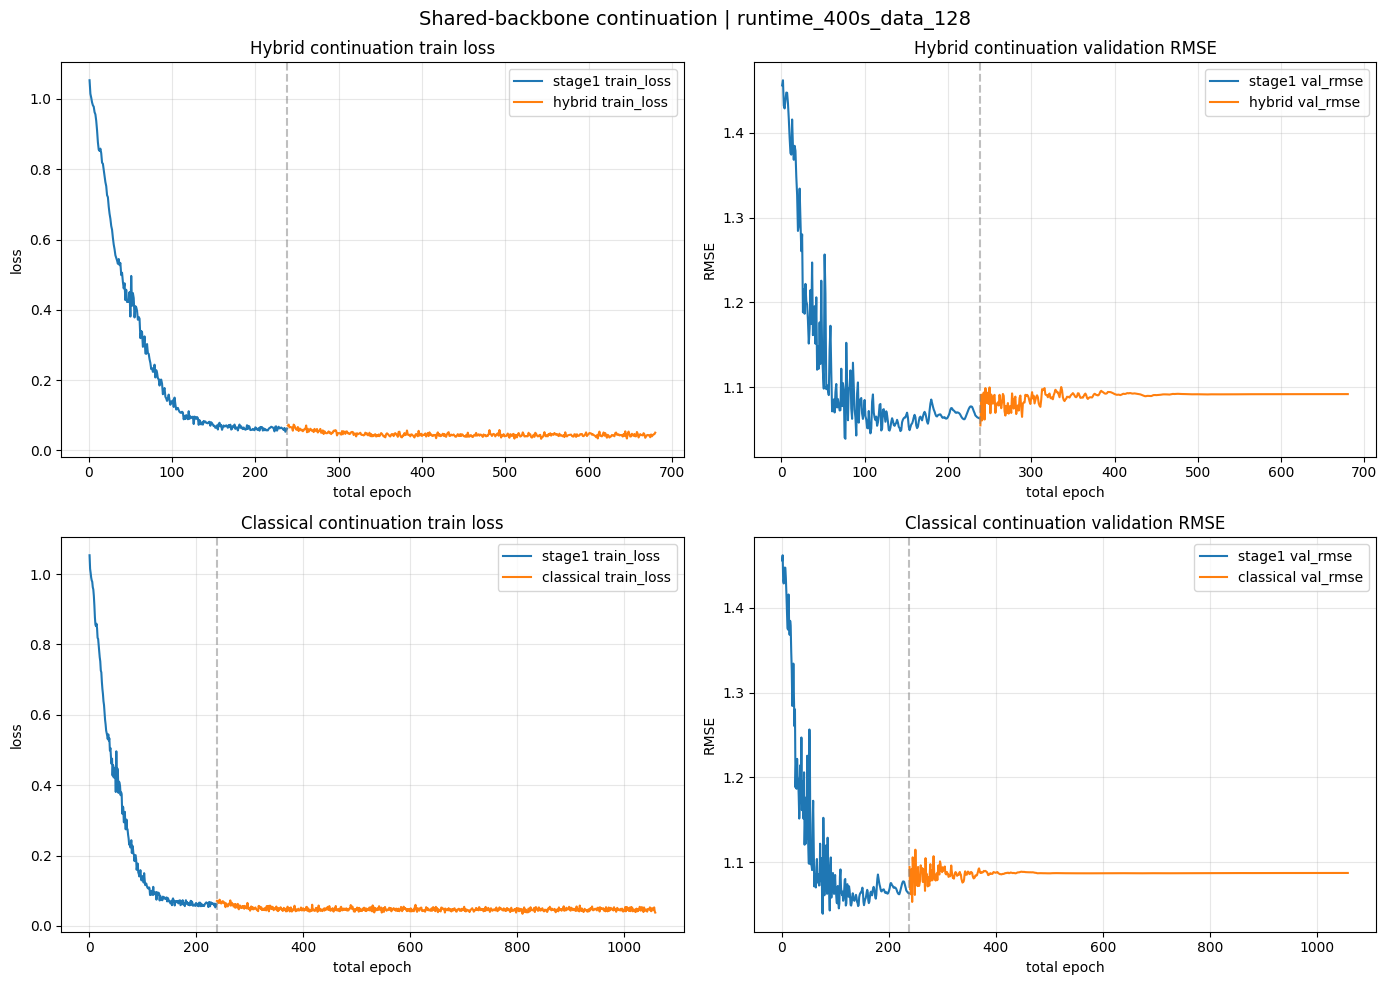

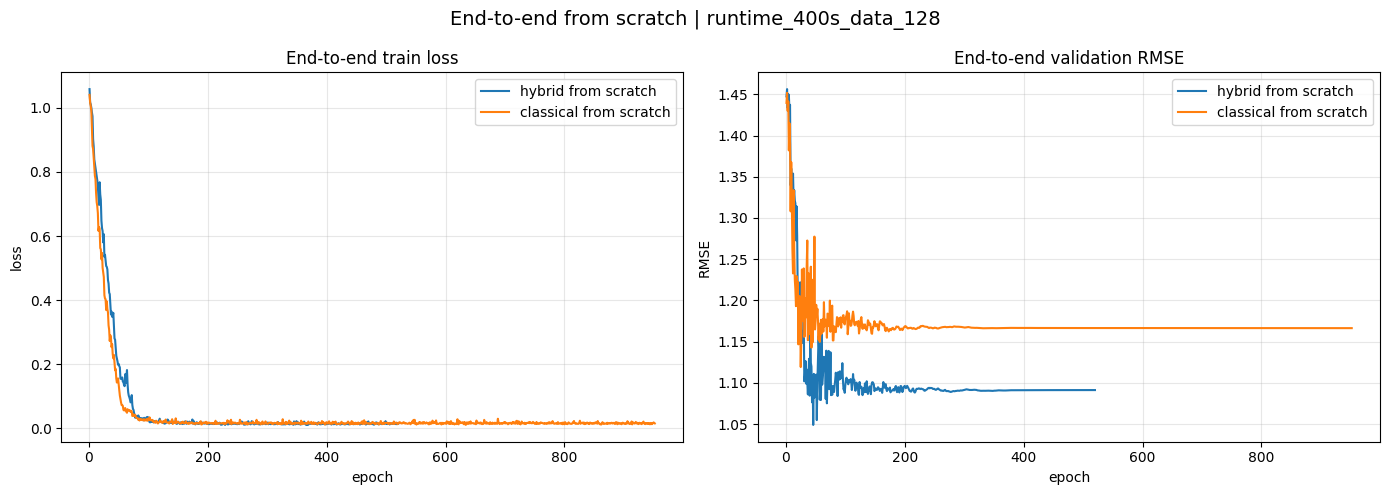

In [29]:
# Plot shared-backbone and end-to-end histories for every finished condition
import re
from pathlib import Path


def discover_condition_dirs(output_root: Path) -> list[Path]:
    direct_conditions = [path for path in output_root.glob("runtime_*") if path.is_dir()]
    if direct_conditions:
        return direct_conditions

    seeded_conditions = []
    for seed_dir in sorted(path for path in output_root.glob("seed_*") if path.is_dir()):
        seeded_conditions.extend(path for path in seed_dir.glob("runtime_*") if path.is_dir())
    return seeded_conditions


def condition_sort_key(condition_dir: Path) -> tuple[int, int, str]:
    match = re.search(r"runtime_(\d+)s_data_(\d+)", condition_dir.name)
    runtime_value = int(match.group(1)) if match else 10**9
    train_rows_value = int(match.group(2)) if match else 10**9
    parent_name = condition_dir.parent.name if condition_dir.parent != PLOT_OUTPUT_ROOT else ""
    return runtime_value, train_rows_value, parent_name


def load_history(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def maybe_plot_with_boundary(ax, stage1_history, stage2_history, y_col: str, stage1_label: str, stage2_label: str, title: str, ylabel: str) -> None:
    stage1_epoch_axis = stage1_history["epoch"] if not stage1_history.empty else pd.Series(dtype=float)
    stage1_last_epoch = int(stage1_epoch_axis.max()) if not stage1_history.empty else 0
    stage2_epoch_axis = stage2_history["epoch"] + stage1_last_epoch if not stage2_history.empty else pd.Series(dtype=float)

    if not stage1_history.empty:
        ax.plot(stage1_epoch_axis, stage1_history[y_col], label=stage1_label)
    if not stage2_history.empty:
        ax.plot(stage2_epoch_axis, stage2_history[y_col], label=stage2_label)
    if not stage1_history.empty and not stage2_history.empty:
        ax.axvline(stage1_last_epoch + 0.5, color="gray", linestyle="--", alpha=0.5)

    ax.set_title(title)
    ax.set_xlabel("total epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    if ax.lines:
        ax.legend()


def maybe_plot_dual_histories(ax, history_a, label_a: str, history_b, label_b: str, y_col: str, title: str, ylabel: str) -> None:
    if not history_a.empty:
        ax.plot(history_a["epoch"], history_a[y_col], label=label_a)
    if not history_b.empty:
        ax.plot(history_b["epoch"], history_b[y_col], label=label_b)
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    if ax.lines:
        ax.legend()


all_condition_dirs = sorted(discover_condition_dirs(PLOT_OUTPUT_ROOT), key=condition_sort_key)
if not all_condition_dirs:
    raise FileNotFoundError(f"No finished condition directories found under {PLOT_OUTPUT_ROOT}")

print(f"Found {len(all_condition_dirs)} finished conditions under {PLOT_OUTPUT_ROOT}")

for condition_dir in all_condition_dirs:
    condition_label = condition_dir.relative_to(PLOT_OUTPUT_ROOT)
    display(Markdown(f"### {condition_label}"))

    legacy_shared_root = condition_dir / "codex"
    shared_root = condition_dir / "codex_shared_backbone" if (condition_dir / "codex_shared_backbone").exists() else legacy_shared_root
    stage1_history = load_history(shared_root / "stage1_classical" / "history.csv")
    stage2_hybrid_history = load_history(shared_root / "stage2_hybrid" / "history.csv")
    stage2_classical_history = load_history(shared_root / "stage2_classical_control" / "history.csv")

    if not stage1_history.empty or not stage2_hybrid_history.empty or not stage2_classical_history.empty:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(f"Shared-backbone continuation | {condition_label}", fontsize=14)

        maybe_plot_with_boundary(
            axes[0, 0],
            stage1_history,
            stage2_hybrid_history,
            y_col="train_loss",
            stage1_label="stage1 train_loss",
            stage2_label="hybrid train_loss",
            title="Hybrid continuation train loss",
            ylabel="loss",
        )
        maybe_plot_with_boundary(
            axes[0, 1],
            stage1_history,
            stage2_hybrid_history,
            y_col="val_rmse_mean",
            stage1_label="stage1 val_rmse",
            stage2_label="hybrid val_rmse",
            title="Hybrid continuation validation RMSE",
            ylabel="RMSE",
        )
        maybe_plot_with_boundary(
            axes[1, 0],
            stage1_history,
            stage2_classical_history,
            y_col="train_loss",
            stage1_label="stage1 train_loss",
            stage2_label="classical train_loss",
            title="Classical continuation train loss",
            ylabel="loss",
        )
        maybe_plot_with_boundary(
            axes[1, 1],
            stage1_history,
            stage2_classical_history,
            y_col="val_rmse_mean",
            stage1_label="stage1 val_rmse",
            stage2_label="classical val_rmse",
            title="Classical continuation validation RMSE",
            ylabel="RMSE",
        )

        plt.tight_layout()
        plt.show()

    e2e_root = condition_dir / "codex_end_to_end"
    e2e_hybrid_history = load_history(e2e_root / "hybrid_from_scratch" / "history.csv")
    e2e_classical_history = load_history(e2e_root / "classical_control_from_scratch" / "history.csv")

    if not e2e_hybrid_history.empty or not e2e_classical_history.empty:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f"End-to-end from scratch | {condition_label}", fontsize=14)

        maybe_plot_dual_histories(
            axes[0],
            e2e_hybrid_history,
            "hybrid from scratch",
            e2e_classical_history,
            "classical from scratch",
            y_col="train_loss",
            title="End-to-end train loss",
            ylabel="loss",
        )
        maybe_plot_dual_histories(
            axes[1],
            e2e_hybrid_history,
            "hybrid from scratch",
            e2e_classical_history,
            "classical from scratch",
            y_col="val_rmse_mean",
            title="End-to-end validation RMSE",
            ylabel="RMSE",
        )

        plt.tight_layout()
        plt.show()